# Hand Tremor Detection using Temporal Deep Learning
## Comparative Study: Temporal Sequence Modeling (LSTM) for Hand Tremor Classification

**Dataset:** MPU9250 Hand Tremor Dataset (Kaggle)
**Model:** LSTM-based temporal sequence classifier
**Task:** Binary classification — Stable (0) vs Tremor (1)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.19.0
GPU: True


## 1. Load & Explore Dataset

In [3]:
# Upload Dataset.csv from the Kaggle MPU9250 Hand Tremor dataset
from google.colab import files
uploaded = files.upload()  # upload Dataset.csv

df = pd.read_csv('Dataset.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nClass distribution:')
print(df['Result'].value_counts())
print(f'\nClass balance: {df["Result"].value_counts(normalize=True).round(3).to_dict()}')
df.head()

Saving Dataset.csv to Dataset.csv
Shape: (27995, 10)
Columns: ['aX', 'aY', 'aZ', 'gX', 'gY', 'gZ', 'mX', 'mY', 'mZ', 'Result']

Class distribution:
Result
1    15246
0    12749
Name: count, dtype: int64

Class balance: {1: 0.545, 0: 0.455}


,aX,aY,aZ,gX,gY,gZ,mX,mY,mZ,Result
0,-2544,14340,-6864,3840,-335,-1518,-1760,-1,-1,1
1,-2380,14188,-5644,3888,1635,-9604,-2419,-1,-1,1
2,-524,14480,-7148,3888,-1663,-1491,311,-1,-1,1
3,-528,15052,-6672,3904,461,-4012,-1424,-1,-1,1
4,-2808,14040,-5936,3904,595,-339,13,-1,-1,1


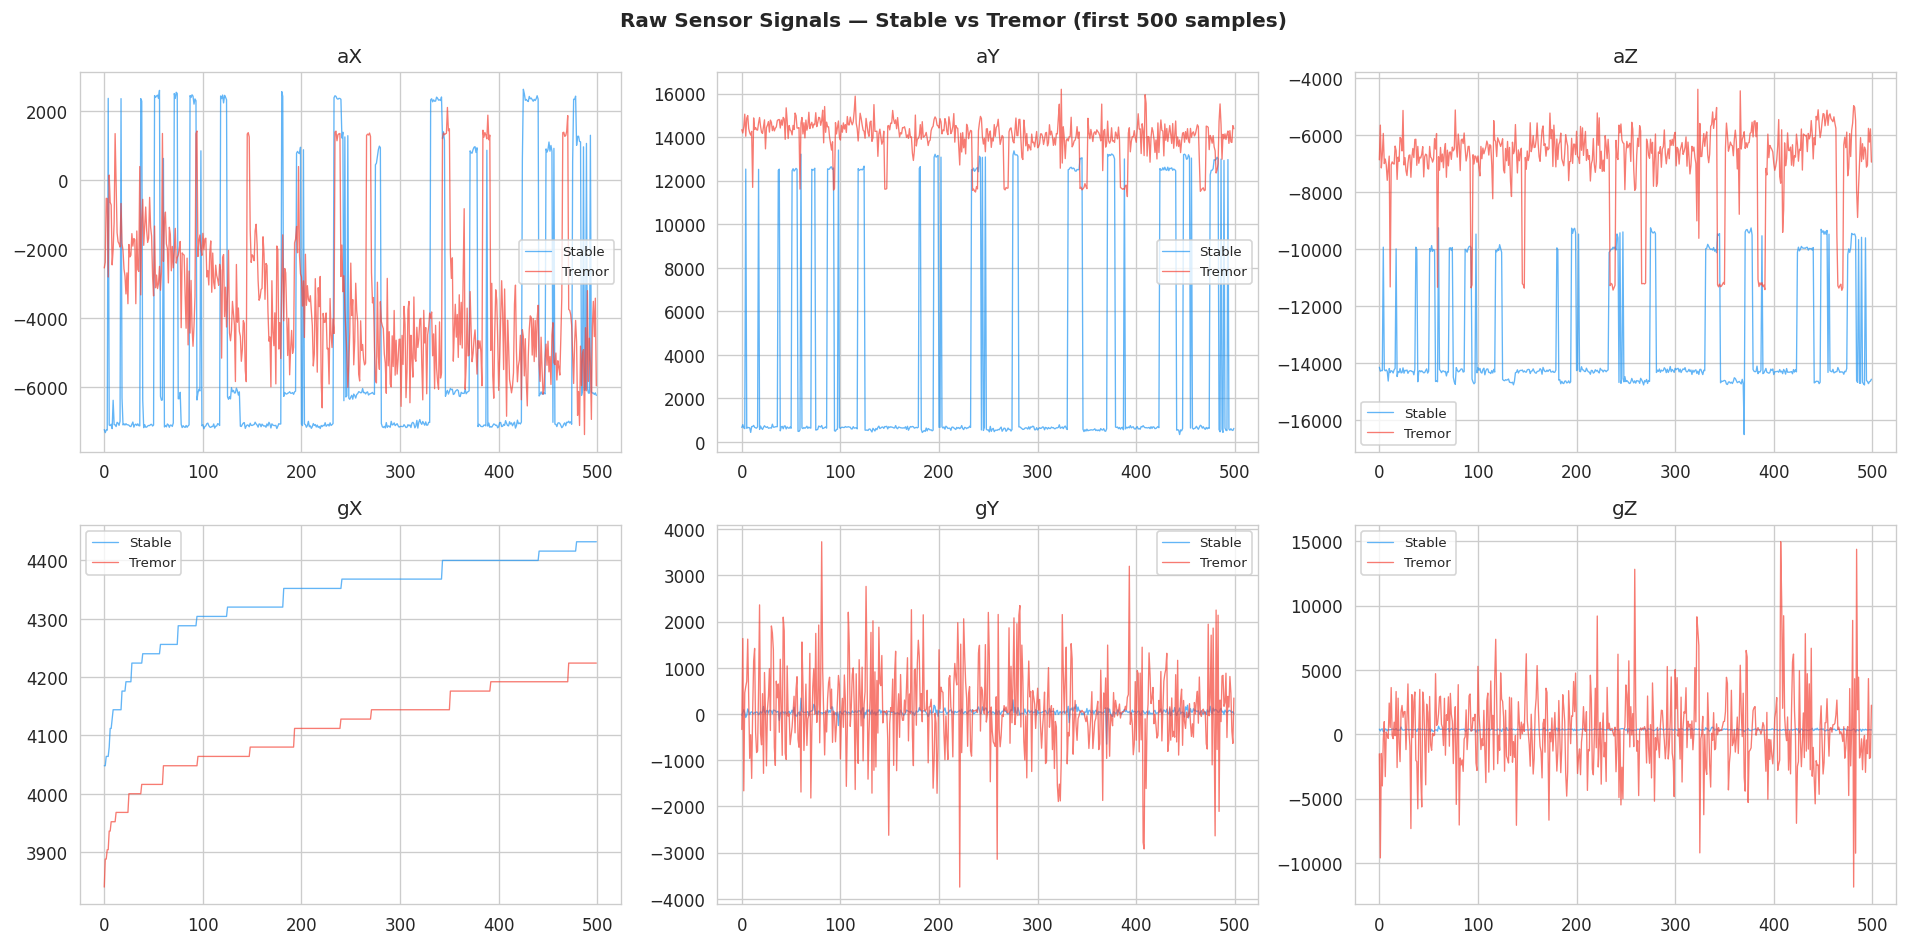

In [4]:
# Visualize raw sensor signals
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
features = ['aX', 'aY', 'aZ', 'gX', 'gY', 'gZ']
colors = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0', '#00BCD4']

for ax, feat, color in zip(axes.flatten(), features, colors):
    stable = df[df['Result']==0][feat].values[:500]
    tremor = df[df['Result']==1][feat].values[:500]
    ax.plot(stable, label='Stable', color='#2196F3', alpha=0.7, linewidth=0.8)
    ax.plot(tremor, label='Tremor', color='#F44336', alpha=0.7, linewidth=0.8)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Raw Sensor Signals — Stable vs Tremor (first 500 samples)', fontweight='bold')
plt.tight_layout()
plt.savefig('raw_signals.png', bbox_inches='tight')
plt.show()

## 2. Preprocessing & Windowing

In [5]:
# Use accelerometer + gyroscope features (drop magnetometer - constant -1)
FEATURE_COLS = ['aX', 'aY', 'aZ', 'gX', 'gY', 'gZ']
LABEL_COL = 'Result'
WINDOW_SIZE = 50   # 50 timesteps per sequence
STEP_SIZE = 25     # 50% overlap

X_raw = df[FEATURE_COLS].values
y_raw = df[LABEL_COL].values

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Create sliding windows
def create_windows(X, y, window_size, step_size):
    X_windows, y_windows = [], []
    for i in range(0, len(X) - window_size, step_size):
        X_windows.append(X[i:i+window_size])
        # majority label in window
        y_windows.append(np.bincount(y[i:i+window_size]).argmax())
    return np.array(X_windows), np.array(y_windows)

X_windows, y_windows = create_windows(X_scaled, y_raw, WINDOW_SIZE, STEP_SIZE)

print(f'Windows shape: {X_windows.shape}  (samples, timesteps, features)')
print(f'Labels shape: {y_windows.shape}')
print(f'Class distribution: {np.bincount(y_windows)}')

# Train/val/test split
X_temp, X_test, y_temp, y_test = train_test_split(X_windows, y_windows, test_size=0.2, random_state=42, stratify=y_windows)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f'\nTrain: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Windows shape: (1118, 50, 6)  (samples, timesteps, features)
Labels shape: (1118,)
Class distribution: [494 624]

Train: (715, 50, 6), Val: (179, 50, 6), Test: (224, 50, 6)


## 3. LSTM Model

In [6]:
def build_lstm(input_shape, lstm_units=64, dropout=0.3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(lstm_units, return_sequences=True),
        layers.Dropout(dropout),
        layers.LSTM(lstm_units // 2),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_lstm(input_shape=(WINDOW_SIZE, len(FEATURE_COLS)))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,681 (123.75 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Training

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
                                   restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print(f'\nBest val accuracy: {max(history.history["val_accuracy"]):.4f}')
print(f'Epochs trained: {len(history.history["loss"])}')

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.6741 - loss: 0.6549 - val_accuracy: 0.7654 - val_loss: 0.5833 - learning_rate: 0.0010
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7441 - loss: 0.5542 - val_accuracy: 0.8101 - val_loss: 0.4451 - learning_rate: 0.0010
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7986 - loss: 0.4550 - val_accuracy: 0.8212 - val_loss: 0.3961 - learning_rate: 0.0010
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8084 - loss: 0.4238 - val_accuracy: 0.8492 - val_loss: 0.3487 - learning_rate: 0.0010
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8531 - loss: 0.3820 - val_accuracy: 0.8715 - val_loss: 0.2912 - learning_rate: 0.0010
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8741 - loss: 0.3538 - val_accuracy: 0.8715 - val_loss: 0.2791 - learning_rate: 0.0010
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8769 - loss: 0.2994 - val_acc

## 5. Evaluation

In [8]:
# Test set evaluation
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

test_acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Stable', 'Tremor']))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
Test Accuracy: 0.9509

Classification Report:
              precision    recall  f1-score   support

      Stable       0.94      0.95      0.94        99
      Tremor       0.96      0.95      0.96       125

    accuracy                           0.95       224
   macro avg       0.95      0.95      0.95       224
weighted avg       0.95      0.95      0.95       224



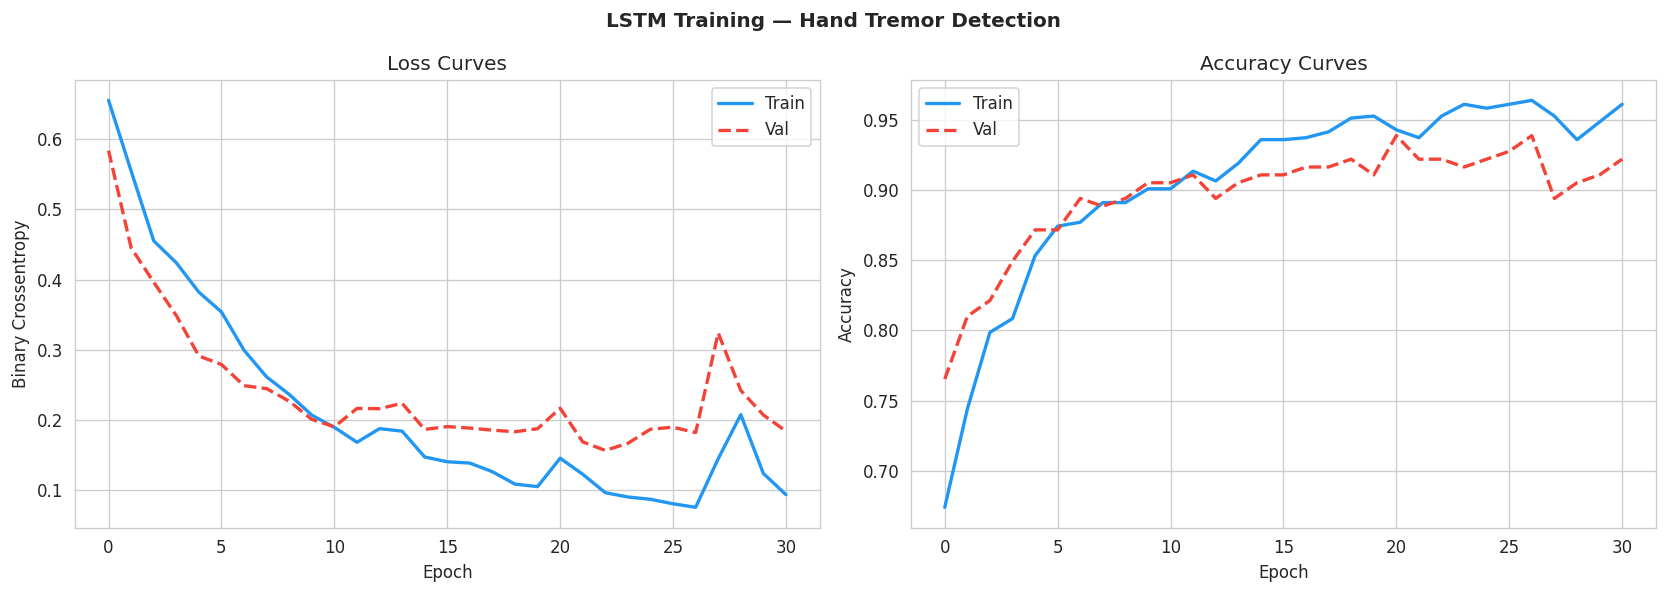

In [9]:
# Loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train', color='#2196F3', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val',   color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train', color='#2196F3', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val',   color='#F44336', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('LSTM Training — Hand Tremor Detection', fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()

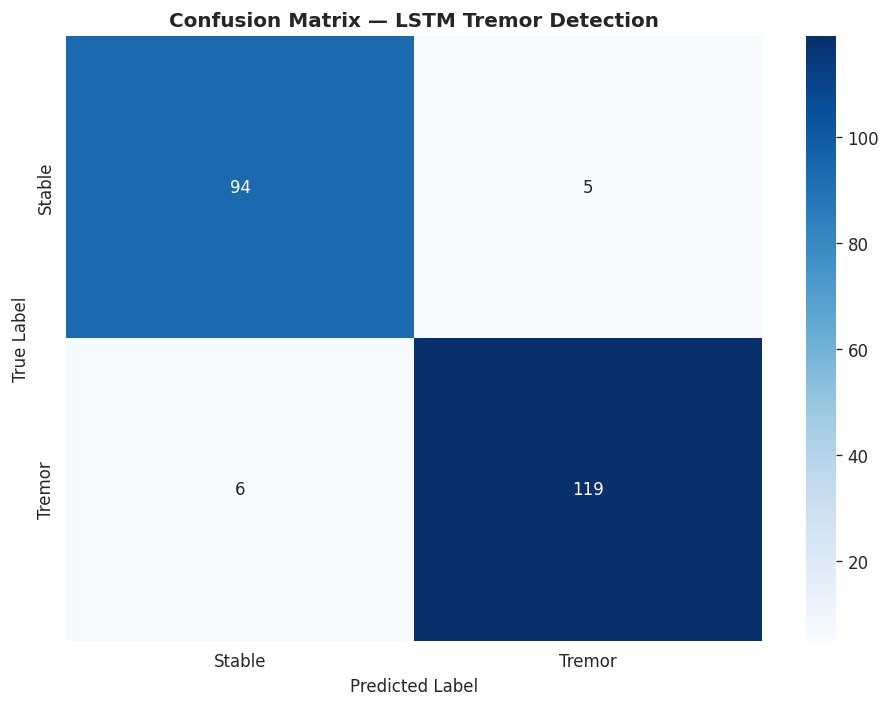


===== FINAL RESULTS =====
Accuracy:  0.9509
Precision: 0.9597
Recall:    0.9520
F1 Score:  0.9558


In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stable', 'Tremor'],
            yticklabels=['Stable', 'Tremor'])
plt.title('Confusion Matrix — LSTM Tremor Detection', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

# Final metrics summary
from sklearn.metrics import precision_score, recall_score, f1_score
print('\n===== FINAL RESULTS =====')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')

## 6. Why Temporal Modeling?

Hand tremor is an **oscillatory phenomenon** — it cannot be detected from a single frame/sample. A single accelerometer reading tells you the current acceleration but not whether it's part of a rhythmic oscillation pattern characteristic of tremor.

The LSTM captures:
- **Temporal dependencies** across 50 consecutive timesteps
- **Oscillation patterns** — tremor typically occurs at 4-12 Hz
- **Sequential context** — whether the current motion is part of a sustained pattern

A frame-based classifier (MLP on single samples) would fail because:
- A single high-acceleration reading could be intentional movement, not tremor
- Tremor is defined by its **rhythmic, involuntary repetition** over time
- Without temporal context, stable and tremor samples can have overlapping feature distributions

This validates the use of sequence modeling (LSTM) over static classification for tremor detection.